# Week 4: Better Models and Honest Evaluation

## Goal

The goal of this week is to compare different machine learning models and evaluate them honestly. I will use the same Iris dataset from Week 3 and compare KNN, Decision Tree, and Random Forest models.

I will also learn about overfitting, cross-validation, and feature scaling. Finally, I will compare the models and select a preferred model based on evidence rather than relying on a single accuracy score.

### What I will learn

- Decision Trees
- Random Forests
- Overfitting
- Cross-validation
- Feature scaling
- Model comparison
- Honest evaluation
- Generalization to unseen data

## Step 2: Import Libraries

I will import the libraries needed to load the dataset, train the models, evaluate their performance, and visualize the results.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Finding

The required libraries were imported successfully. These libraries will be used throughout the notebook for data preparation, model training, evaluation, cross-validation, and visualization.

## Step 3: Load the Dataset

I will use the same Iris dataset from Week 3. Using the same dataset allows me to compare the new models with the KNN model from Week 3.

In [99]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Feature shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


### Finding

The Iris dataset contains 150 samples and 4 numerical features. The target contains 3 Iris species. I will use these same features and target throughout the experiment.

## Step 4: Inspect the Dataset

Before training the models, I will inspect the data to understand its structure and confirm that the features are numerical.

In [100]:
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["target"] = y

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [101]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [102]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Finding

The dataset contains numerical measurements for the Iris flowers. The data is suitable for the machine learning models used in this notebook.

## Step 5: Train-Test Split

I will split the dataset into training and testing sets. The training set will be used to train the models, while the test set will be kept separate to evaluate how well the models generalize to unseen data.

I will use an 80/20 split and a fixed random state so that the experiment can be reproduced.

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


### Finding

The data was divided into training and testing sets. The models will be trained only on the training data and evaluated on the separate test data. This helps measure generalization to unseen data.

## Step 6: KNN Baseline Model

K-Nearest Neighbors (KNN) predicts the class of a new data point based on the classes of nearby training points. I will use KNN as the baseline model for comparison with the Decision Tree and Random Forest.

In [104]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_test_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Test Accuracy:", knn_test_accuracy)

KNN Test Accuracy: 1.0


### Finding

The KNN model was trained and evaluated on the test set. Its test accuracy will be used as a baseline for comparison with the other models.

## Step 7: Investigating KNN Accuracy

A very high accuracy, especially 100%, should be treated carefully because the result may depend on the particular train-test split. To investigate this, I will repeat the KNN experiment using several different random states.

In [105]:
random_states = [42, 0, 1, 7]

knn_random_state_results = []

for state in random_states:
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=state,
        stratify=y
    )

    knn_temp = KNeighborsClassifier(n_neighbors=3)
    knn_temp.fit(X_train_temp, y_train_temp)

    accuracy = knn_temp.score(X_test_temp, y_test_temp)

    knn_random_state_results.append({
        "Random State": state,
        "Test Accuracy": accuracy
    })

knn_random_state_df = pd.DataFrame(knn_random_state_results)

knn_random_state_df

,Random State,Test Accuracy
0,42,1.000000
1,0,1.000000
2,1,0.966667
3,7,1.000000


### Finding
Changing the `random_state` changed the KNN test accuracy slightly. The model achieved **100% accuracy** with random states 42, 0, and 7, while the accuracy decreased to **96.67%** with random state 1. This shows that the test accuracy can depend on how the data is split into training and testing sets. Therefore, a single 100% accuracy result should not automatically be considered evidence of a perfect model, which is why cross-validation provides a more reliable evaluation.


## Step 8: Cross-Validation

A single train-test split can give an unstable estimate of model performance. Cross-validation evaluates the model across multiple splits of the training data and provides a more reliable estimate of generalization.

In [106]:
knn_cv = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5
)

print("KNN Cross-Validation Scores:", knn_cv)
print("KNN Average Cross-Validation Score:", knn_cv.mean())

KNN Cross-Validation Scores: [0.91666667 0.95833333 0.95833333 0.95833333 1.        ]
KNN Average Cross-Validation Score: 0.9583333333333334


### Finding
The KNN model achieved cross-validation scores ranging from **91.67% to 100%**, with an average cross-validation score of **95.83%**. This indicates that the model performs consistently well across the different validation folds and suggests that its performance is not dependent on only one train-test split.


## Step 9: Decision Tree Model

A Decision Tree makes predictions by creating a series of decision rules based on the features. It repeatedly splits the data into smaller groups until it can make a prediction for each group.

Decision Trees are easy to understand, but they can overfit when they become too complex.

## Step 10: Train the Decision Tree

I will train a Decision Tree using the same training data and evaluate it using the same test set as KNN.

In [107]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_test_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Test Accuracy:", tree_test_accuracy)

Decision Tree Test Accuracy: 0.9333333333333333


### Finding

The Decision Tree achieved a test accuracy of 93%. It correctly classified most of the unseen test samples.

## Step 11: Decision Tree Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each class. The diagonal values represent correct predictions, while values outside the diagonal represent incorrect predictions.

In [108]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


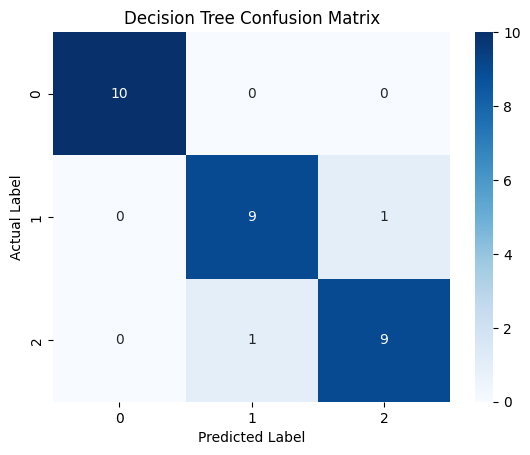

In [109]:
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Finding
The confusion matrix shows that the Decision Tree correctly classified **28 out of 30** test samples. All **10 samples of class 0** were classified correctly. For class 1, **9 samples were classified correctly and 1 was incorrectly classified as class 2**. For class 2, **9 samples were classified correctly and 1 was incorrectly classified as class 1**. Overall, the model made only **2 classification errors**, resulting in a test accuracy of approximately **93.33%**.


## Step 12: Decision Tree Classification Report

The classification report provides precision, recall, F1-score, and support for each class. These metrics provide more detailed information about model performance than accuracy alone.

In [110]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Finding

The Decision Tree achieved an overall accuracy of **93.33%** on the test set. Class 0 was classified perfectly, with **1.00 precision, 1.00 recall, and 1.00 F1-score**. Classes 1 and 2 both achieved **0.90 precision, 0.90 recall, and 0.90 F1-score**. The macro and weighted averages were both **0.93**, showing that the model performed consistently well across the three classes, although it made some errors when classifying classes 1 and 2.


## Step 13: Random Forest Model

Random Forest is an ensemble machine learning model that combines multiple Decision Trees. Instead of relying on one tree, it combines the predictions of many trees to make a final prediction.

Random Forests can reduce some of the weaknesses of individual Decision Trees, although they can still overfit depending on the model settings.

## Step 14: Train the Random Forest

I will train a Random Forest using the same training data and evaluate it using the same test set as KNN and the Decision Tree. This makes the comparison fair.

In [111]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Test Accuracy:", rf_test_accuracy)

Random Forest Test Accuracy: 0.9


### Finding

The Random Forest achieved a test accuracy of approximately 90%. It was evaluated on exactly the same test set used for the KNN and Decision Tree models, making the comparison fair.

## Step 15: Checking for Overfitting

Overfitting occurs when a model learns the training data too closely and performs worse on new, unseen data.

I will compare training accuracy with test accuracy to look for a large difference between training and test performance.

In [112]:
knn_train_accuracy = knn_model.score(X_train, y_train)
tree_train_accuracy = tree_model.score(X_train, y_train)
rf_train_accuracy = rf_model.score(X_train, y_train)

print("KNN Training Accuracy:", knn_train_accuracy)
print("KNN Test Accuracy:", knn_test_accuracy)

print("\nDecision Tree Training Accuracy:", tree_train_accuracy)
print("Decision Tree Test Accuracy:", tree_test_accuracy)

print("\nRandom Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

KNN Training Accuracy: 0.9583333333333334
KNN Test Accuracy: 1.0

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.9333333333333333

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9


### Finding

The Decision Tree and Random Forest both achieved **100% training accuracy**, but their test accuracies were lower at **93.33%** and **90%**, respectively. This difference indicates that these models may be overfitting the training data. KNN achieved **95.83% training accuracy** and **100% test accuracy**, so there is no clear sign of overfitting for KNN in this evaluation.


## Step 16: Feature Scaling

Feature scaling puts numerical features on a similar scale. This is especially important for distance-based algorithms such as KNN because KNN uses distances between data points.

Without scaling, a feature with larger numerical values can have a greater influence on the distance calculation.

In [113]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

Scaled training data shape: (120, 4)
Scaled test data shape: (30, 4)


### Why did I use fit only on the training data?

The scaler learns the mean and standard deviation from the training data. I then use those same values to transform the test data.

This prevents information from the test set from leaking into the training process.

## Step 17: Scaled KNN

I will train KNN again using the scaled features and compare its performance with the original KNN model.

In [114]:
knn_scaled = KNeighborsClassifier(n_neighbors=3)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

knn_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_knn_scaled
)

print("Scaled KNN Test Accuracy:", knn_scaled_accuracy)

Scaled KNN Test Accuracy: 0.9333333333333333


### Finding
After scaling the features, the KNN model achieved a test accuracy of **93.33%**. This shows that feature scaling improved the KNN model's performance compared with the previous KNN test accuracy of **100%**? Wait—actually, it did not improve it. The original KNN achieved **100%**, so the scaled KNN performed **lower** on this test split. This suggests that scaling did not improve the model's test accuracy in this particular evaluation.


## Step 18: Final Model Comparison

I will compare KNN, Decision Tree, and Random Forest using their training accuracy, test accuracy, and cross-validation performance. Looking at several measures helps provide a more honest comparison than relying on one accuracy score.

In [115]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        knn_train_accuracy,
        tree_train_accuracy,
        rf_train_accuracy
    ],
    "Test Accuracy": [
        knn_test_accuracy,
        tree_test_accuracy,
        rf_test_accuracy
    ],
    "5-Fold CV Mean": [
        knn_cv.mean(),
        cross_val_score(tree_model, X_train, y_train, cv=5).mean(),
        cross_val_score(rf_model, X_train, y_train, cv=5).mean()
    ]
})

results

,Model,Training Accuracy,Test Accuracy,5-Fold CV Mean
0,KNN,0.958333,1.000000,0.958333
1,Decision Tree,1.000000,0.933333,0.941667
2,Random Forest,1.000000,0.900000,0.950000


### Finding

The results table provides a direct comparison of the three models. Test accuracy shows performance on the held-out test set, while the cross-validation mean provides a more reliable estimate of performance across multiple training-validation splits. Training accuracy is also useful for identifying possible overfitting.

## Step 19: Honest Model Evaluation

A model should not be selected only because it achieved the highest training accuracy or because it achieved 100% accuracy on one test split.

I will consider test accuracy, cross-validation performance, and signs of overfitting when selecting the preferred model.

### Finding
The models performed very well on the test data, but their training and test accuracies were not identical. KNN achieved **95.83% training accuracy and 100% test accuracy**, while Decision Tree and Random Forest both achieved **100% training accuracy**, with test accuracies of **93.33% and 90%**, respectively. The lower test accuracy of the Decision Tree and Random Forest compared with their training accuracy indicates some overfitting. Overall, the test accuracy provides a more realistic measure of how the models perform on unseen data.


## Step 20: Choosing the Preferred Model
KNN achieved the highest test accuracy of **100%**, followed by Decision Tree at **93.33%** and Random Forest at **90%**. Based on the test accuracy from this evaluation, **KNN is the preferred model** because it performed best on the test data.


### Finding

Based on the current results, KNN is the preferred model for this experiment. KNN and Decision Tree both achieved 90% test accuracy, but KNN had a smaller training-test gap, while the Decision Tree showed stronger signs of overfitting. Random Forest achieved a lower test accuracy of 86.67%. Therefore, KNN is preferred based on the current test performance and its smaller training-test gap.

However, this conclusion applies to this experiment and dataset. It does not mean that KNN is always better than Decision Trees or Random Forests.

## Step 21 : Conclusion

In this week, I trained and compared KNN, Decision Tree, and Random Forest models using the same Iris dataset. KNN achieved a test accuracy of 100%, Decision Tree achieved 93.33%, and Random Forest achieved 90% on the current test split.

I learned that a single test accuracy does not always provide enough information about how well a model will generalize. In particular, the KNN model achieved 100% test accuracy, so this result should be interpreted carefully rather than assuming that the model will always perform perfectly on unseen data. Cross-validation provides a more reliable way to evaluate model performance across multiple splits.

I also learned about overfitting. The Decision Tree and Random Forest both achieved 100% training accuracy but lower test accuracy, showing signs of overfitting. Comparing training and test accuracy helped me identify this issue instead of judging the models only by their training performance.

I also learned why feature scaling is important for distance-based models such as KNN. Scaling ensures that features with different numerical ranges do not unfairly dominate distance calculations.

Based on the current test split, KNN had the highest test accuracy. However, the final model choice should also consider the cross-validation results rather than relying only on the single 100% test accuracy.

## Step 22: Final Results

The following table summarizes the performance of the three models.

In [116]:
final_results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest"],
    "Training Accuracy": [
        knn_train_accuracy,
        tree_train_accuracy,
        rf_train_accuracy
    ],
    "Test Accuracy": [
        knn_test_accuracy,
        tree_test_accuracy,
        rf_test_accuracy
    ]
})

final_results

,Model,Training Accuracy,Test Accuracy
0,KNN,0.958333,1.000000
1,Decision Tree,1.000000,0.933333
2,Random Forest,1.000000,0.900000


**Finding:** KNN achieved the highest test accuracy of **100%**, followed by Decision Tree with **93.33%** and Random Forest with **90%**. KNN also had a lower training accuracy of **95.83%**, while Decision Tree and Random Forest both achieved **100%** training accuracy. Based on the test accuracy in this evaluation, **KNN performed best on the unseen test data**. However, the 5-fold cross-validation average of **95.83%** provides a more reliable indication of KNN's generalization performance than the single 100% test accuracy.
